# Arboles de Decisión 

Importa las librerias
- pandas - manejo de datos
- matplotlib - graficos
- sklear - algoritmos de clasificacion, cluster, etc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [ ]:
#%pip install pandas
#%pip install scikit-learn
#%pip install openpyxl

### Ejercicio 1: Diagnosticar  a un paciente 

Archivo: diagnostivo.csv

In [ ]:
datos = pd.read_csv('Dataset/diagnostico.csv')
datos.head()

Eliminamos el atributo ``Patient ID``

In [ ]:
datos.drop('Patient ID', axis=1, inplace=True)
datos.head(3)

Cambiar las etiquetas de las variables independientes y dependiente

In [ ]:
datos = datos.rename(columns={'Sore throat': 'Garganta', 'Fever': 'Fiebre',
                                'Swollen Glands': 'inflamadas','Congestion': 'Congestion', 'Headache':'Dolor','Diagnosis': 'Diagnostico'})
datos.head(3)

In [ ]:
# traducimos los diagnosticos a español
d = {'Strep thoat':'Faringitis', 'Allergy': 'Alergia', 'Cold':'Resfriado'}
datos['Diagnostico'] = datos ['Diagnostico'].map(d)
datos.head()

In [ ]:
#Variable de diagnostico
diagnostico = datos.Diagnostico.unique().tolist()
print(diagnostico)

Cambiar los valores categoricos - nominales a valores numericos 
- Yes = 1             No=0
- Faringitis = 0 , alergia = 1, Resfriado = 2


In [ ]:
atributos = datos.columns.tolist()
for atri in atributos:
    if atri != 'Diagnostico':
        datos[atri] = datos[atri].map({'Yes': 1, 'No': 0})
    else:
        datos[atri] = datos[atri].map({'Faringitis': 0, 'Alergia': 1, 'Resfriado': 2})
datos.head(3)


In [ ]:
vi = datos.columns[:-1].tolist()
x = datos[vi].values
y = datos['Diagnostico']

Seleccionar el algoritmo y entrenarlo

In [32]:
dtree = DecisionTreeClassifier()
dtree.fit(x, y) # Entrenamiento del modelo .fit()  --> Aprende el algoritmo a partir de los datos de entrenamiento (x) y las etiquetas (y)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

Predecir el diagnostico

In [ ]:
dtree.predict([[0, 0, 0, 0, 0]])

Generar las reglas a partir del arbol de clasificacion generado

In [ ]:
from sklearn import tree
reglas_arbol = tree.export_text(dtree, feature_names=vi, class_names=diagnostico, show_weights=True)
print(reglas_arbol)

Graficar el arbol

In [ ]:
arbol = tree.plot_tree(dtree, feature_names=vi, class_names=diagnostico, filled=True, impurity=False, proportion=True)
plt.show()

MODELO PARA PREDECIR SI UNA PERSONA ASISTIRA A UN EVENTO O NO

-

In [2]:
datos = pd.read_csv('Dataset/eventos.csv')
print(datos.shape)
datos.head()

(15, 5)


,Edad,Experiencia,Calificacion,Pais,Asistir
0,36,10,6,Ecuador,Si
1,27,8,7,Colombia,No
2,45,1,8,Argentina,Si
3,18,2,5,Argentina,Si
4,31,4,8,Mexico,Si


In [ ]:
# informacion de los dataframes
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Edad          15 non-null     int64
 1   Experiencia   15 non-null     int64
 2   Calificacion  15 non-null     int64
 3   Pais          15 non-null     str  
 4   Asistir       15 non-null     str  
dtypes: int64(3), str(2)
memory usage: 732.0 bytes


In [ ]:
# resumen estadistico del dataset
datos.describe()

,Edad,Experiencia,Calificacion
count,15.000000,15.000000,15.000000
mean,28.866667,4.466667,6.800000
std,8.830682,3.270357,1.656157
min,18.000000,0.000000,3.000000
25%,23.000000,2.000000,6.000000
50%,27.000000,4.000000,7.000000
75%,32.000000,7.500000,8.000000
max,48.000000,10.000000,9.000000


Mapear los atributos no numericos

In [ ]:
datos['Pais'] = datos['Pais'].map({'Ecuador': 0, 'Colombia': 1, 'Argentina': 2, 'Mexico': 3})
datos['Asistir'] = datos['Asistir'].map({'No': 0, 'Si': 1})
datos.head(3)


,Edad,Experiencia,Calificacion,Pais,Asistir
0,36,10,6,0,1
1,27,8,7,1,0
2,45,1,8,2,1


In [8]:
datos.Pais.value_counts()

Pais
0    5
1    4
2    3
3    3
Name: count, dtype: int64

In [6]:

datos.Asistir.value_counts()

Asistir
1    8
0    7
Name: count, dtype: int64

Dividir en variables independientes y variable dependiente

In [4]:
vi= datos.columns[:-1].tolist()
print(vi)
x = datos[vi].values
y = datos['Asistir']


['Edad', 'Experiencia', 'Calificacion', 'Pais']


Aplicamos el algoritmo de clasificacion, entrenamos (aprende) y predecir

In [5]:
dtree = DecisionTreeClassifier() #algoritmo de clasificacion
dtree.fit(x, y) # Entrenamiento del modelo .fit()  --> Aprende el algoritmo a partir de los datos de entrenamiento (x) y las etiquetas (y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [11]:
datos.columns

Index(['Edad', 'Experiencia', 'Calificacion', 'Pais', 'Asistir'], dtype='str')

In [13]:
dtree.predict([[40, 7, 6, 0]]) # Ecuador y si asiste
#dtree.predict([[18, 3, 10, 3]]) # Mexico y si asiste 
#dtree.predict([[27, 8, 7, 4]]) # Colombiano y no asiste

array([1])

reglas del arbol de clasificacion

In [24]:
from sklearn import tree
reglas_arbol = tree.export_text(dtree, feature_names=vi, class_names=["No","Si"], show_weights=True, decimals=0, spacing=5)
print(reglas_arbol)

|----- Edad <= 21
|     |----- weights: [0, 3] class: Si
|----- Edad >  21
|     |----- Edad <= 30
|     |     |----- weights: [6, 0] class: No
|     |----- Edad >  30
|     |     |----- Experiencia <= 8
|     |     |     |----- weights: [0, 3] class: Si
|     |     |----- Experiencia >  8
|     |     |     |----- Pais <= 0
|     |     |     |     |----- weights: [0, 1] class: Si
|     |     |     |----- Pais >  0
|     |     |     |     |----- weights: [2, 0] class: No



graficamos el arbol

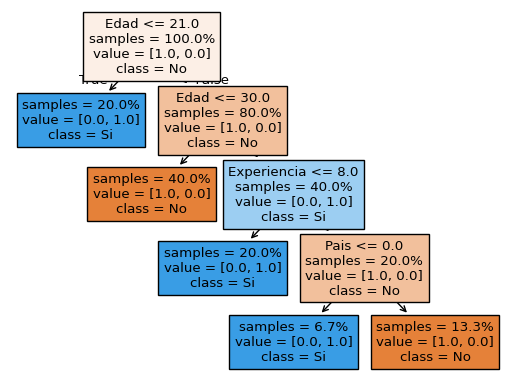

In [29]:
arbol = tree.plot_tree(dtree, feature_names=vi, class_names=["No","Si"], filled=True, impurity=False, proportion=True, precision=0) 
plt.show()

## ME GUSTA EL CINE ?


In [32]:
datos=pd.read_excel('Dataset/Cine.xlsx')
print(datos.shape)
datos.head()

(7, 4)


,Popcorn,Soda,Edad,Cine
0,1,1,7,0
1,1,0,12,0
2,0,1,18,1
3,0,1,35,1
4,1,1,38,1


In [36]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Popcorn  7 non-null      int64
 1   Soda     7 non-null      int64
 2   Edad     7 non-null      int64
 3   Cine     7 non-null      int64
dtypes: int64(4)
memory usage: 356.0 bytes


In [33]:
vi = datos.columns[:-1].tolist()
print(vi)
x = datos[vi].values
y = datos['Cine']

['Popcorn', 'Soda', 'Edad']


In [34]:
dtree = DecisionTreeClassifier() #algoritmo de clasificacion
dtree.fit(x, y) # Entrenamiento del modelo .fit()  --> Aprende el algoritmo a partir de los datos de entrenamiento (x) y las etiquetas (y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [35]:
datos.columns

Index(['Popcorn', 'Soda', 'Edad', 'Cine'], dtype='str')

In [49]:

pre1 = dtree.predict([[1, 1, 18]])[0] 
pre2 =dtree.predict([[0, 0, 25]])[0]
map = {0: 'No me gusta', 1: 'Si me gusta'}
print(pre1)
print(pre2)
print(map[pre1])
print(map[pre2])


1
0
Si me gusta
No me gusta


In [45]:
from sklearn import tree
reglas_arbol = tree.export_text(dtree, feature_names=vi, class_names=["No","Si"], show_weights=True, decimals=0, spacing=5)
print(reglas_arbol)

|----- Soda <= 0
|     |----- weights: [3, 0] class: No
|----- Soda >  0
|     |----- Edad <= 12
|     |     |----- weights: [1, 0] class: No
|     |----- Edad >  12
|     |     |----- weights: [0, 3] class: Si



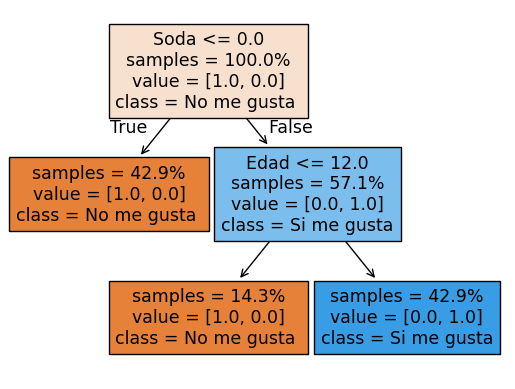

In [41]:
arbol = tree.plot_tree(dtree, feature_names=vi, class_names=["No me gusta ","Si me gusta"], filled=True, impurity=False, proportion=True, precision=0)
plt.show()